# Fichiers

In [14]:
# opération de haut niveau : copie, copie récursive, suppression récursive
import shutil

import csv
import json

import pandas as pd

# import xml.etree as et
import lxml.etree as et

# regexp (stdlib Python)
import re

# HTTP queries
import requests

# module moderne de Python 3
from pathlib import Path
# module plus ancien maintenu : os.

# Images: https://pillow.readthedocs.io/
from PIL import Image

from datetime import date, datetime, timedelta

# scrapping
from bs4 import BeautifulSoup

## Système de fichiers

In [62]:
data_path = Path("data")
data_path

WindowsPath('data')

In [63]:
data_path.exists() and data_path.is_dir()

True

In [64]:
current_dir = Path(".")
current_dir

WindowsPath('.')

In [65]:
print(current_dir.absolute())
print(data_path.absolute())

c:\Users\matth\Documents\Formation\Python\stage_python20260615_poo
c:\Users\matth\Documents\Formation\Python\stage_python20260615_poo\data


In [66]:
data_input_dir = 'C:\\Input\\data'
data_input_path = Path(data_input_dir)
data_input_path

WindowsPath('C:/Input/data')

In [67]:
data_input_dir = 'C:/Input/data'
data_input_path = Path(data_input_dir)
data_input_path

WindowsPath('C:/Input/data')

In [68]:
backup_path = data_path / "backup" / f"{date.today()}"
backup_path

WindowsPath('data/backup/2026-06-18')

In [69]:
backup_path.exists()

True

In [70]:
backup_path.mkdir(parents=True, exist_ok=True)
backup_path.exists() and backup_path.is_dir()

True

In [71]:
list(data_path.iterdir())

[WindowsPath('data/backup'),
 WindowsPath('data/sauvegarde'),
 WindowsPath('data/villes.csv'),
 WindowsPath('data/villes100k.csv'),
 WindowsPath('data/villes100k.json'),
 WindowsPath('data/villes100k.xlsx'),
 WindowsPath('data/villes100k.xml'),
 WindowsPath('data/villes100k_win1252.csv'),
 WindowsPath('data/villes_fr.csv'),
 WindowsPath('data/villes_top5.csv')]

In [72]:
for p in data_path.iterdir():
    print(p)

data\backup
data\sauvegarde
data\villes.csv
data\villes100k.csv
data\villes100k.json
data\villes100k.xlsx
data\villes100k.xml
data\villes100k_win1252.csv
data\villes_fr.csv
data\villes_top5.csv


In [73]:
for p in data_path.glob("villes100k*.*"):
    stats = p.stat()
    dt_creation = datetime.fromtimestamp(stats.st_birthtime)
    dt_modification = datetime.fromtimestamp(stats.st_mtime)
    dt_access = datetime.fromtimestamp(stats.st_atime)
    print(p)
    print(f"\t- fichier data : {p.is_file()}")
    print(f"\t- taille : {stats.st_size} o")
    print(f"\t- date création : {dt_creation}")
    print(f"\t- date dernière modif : {dt_modification}")
    print(f"\t- date dernier accès : {dt_access}")
    shutil.copy2(p, backup_path)


data\villes100k.csv
	- fichier data : True
	- taille : 2162 o
	- date création : 2026-06-18 08:56:09.144640
	- date dernière modif : 2026-06-18 08:57:25.261640
	- date dernier accès : 2026-06-18 13:28:46.761811
data\villes100k.json
	- fichier data : True
	- taille : 7707 o
	- date création : 2026-06-18 08:56:09.154618
	- date dernière modif : 2026-06-18 08:57:25.271639
	- date dernier accès : 2026-06-18 09:05:47.024020
data\villes100k.xlsx
	- fichier data : True
	- taille : 7274 o
	- date création : 2026-06-18 08:56:31.675221
	- date dernière modif : 2026-06-18 08:57:25.629488
	- date dernier accès : 2026-06-18 13:59:59.334027
data\villes100k.xml
	- fichier data : True
	- taille : 12089 o
	- date création : 2026-06-18 08:48:52.957649
	- date dernière modif : 2026-06-18 08:57:25.644487
	- date dernier accès : 2026-06-18 09:05:55.410886
data\villes100k_win1252.csv
	- fichier data : True
	- taille : 2141 o
	- date création : 2026-06-18 08:56:09.145640
	- date dernière modif : 2026-06-18 0

In [74]:
dt_epoch = datetime(1970, 1, 1)
dt_epoch + timedelta(seconds=1781765769.14464)

datetime.datetime(2026, 6, 18, 6, 56, 9, 144640)

In [75]:
new_path = data_path / 'sauvegarde'
if not new_path.exists():
    backup_path.parent.rename(new_path)
    print("Renommage avec succès")
else:
    print(f"Echec renommage: {new_path} existe déjà")

Echec renommage: data\sauvegarde existe déjà


In [76]:
pytest_cache_path = Path('.pytest_cache')
if pytest_cache_path.exists() and pytest_cache_path.is_dir():
    print("Suppression:", pytest_cache_path)
    # pytest_cache_path.rmdir() # ok if empty
    shutil.rmtree(pytest_cache_path)
    print("Done")

In [77]:
dummy_path = data_path / "dummy.txt"
dummy_path.touch()
dummy_path.exists() and dummy_path.is_file()

True

In [78]:
dummy_path.unlink()
assert not dummy_path.exists()

## Lecture et Ecriture de fichiers

### Builtin open

In [79]:
# default mode : r (read) + t (text)
f = open('data/villes100k.csv', encoding='utf-8')
f

<_io.TextIOWrapper name='data/villes100k.csv' mode='r' encoding='utf-8'>

In [80]:
f.readline()

'nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2\n'

In [81]:
# f est un iterator sur le contenu du fichier, ligne par ligne
for line in f:
    print(line, end='')

Nice,Nice,06,Alpes-Maritimes,06000,348085,74
Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
Caen,Caen,14,Calvados,14000,108200,26
Dijon,Dijon,21,Côte-d'Or,21000,159346,42
Besançon,Besançon,25,Doubs,25000,119198,65
Brest,Brest,29,Finistère,29200,139619,49
Nîmes,Nîmes,30,Gard,30900,148104,161
Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
Bordeaux,Bordeaux,33,Gironde,33300,261804,50
Montpellier,Montpellier,34,Hérault,34080,302454,57
Rennes,Rennes,35,Ille-et-Vilaine,35700,225081,50
Tours,Tours,37,Indre-et-Loire,37100,137658,33
Grenoble,Grenoble,38,Isère,38000,157477,19
Saint-Étienne,Saint-Étienne,42,Loire,42100,172718,80
Nantes,Nantes,44,Loire-Atlantique,44200,323204,66
Orléans,Orléans,45,Loiret,45000,116617,28
Angers,Angers,49,Maine-et-Loire,49000,157175,44
Reims,Reims,51,Marne,51100,179380,47
Nancy,Nancy,54,Meurthe-et-Moselle,54100,104260,15
Metz,Metz,57,Moselle,57070,120874,42
Lille,Lille,59,Nord,59260,

In [82]:
f.close()

In [83]:
with open('data/villes100k.csv', encoding='utf-8') as f:
    headers = f.readline().strip()
    # raise ValueError("Dummy error")
    # data = list(f) # lignes en l'état (avec \n)
    data = list(line.strip() for line in f)
# auto : f.close() même si il y a exception
assert f.closed
print(headers)
for line in data[:3]:
    print(line)

nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
Nice,Nice,06,Alpes-Maritimes,06000,348085,74
Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241


In [84]:
ville_infos = line.split(',')
ville_infos

['Marseille', 'Marseille', '13', 'Bouches-du-Rhône', '13000', '873076', '241']

In [85]:
';'.join(ville_infos)

'Marseille;Marseille;13;Bouches-du-Rhône;13000;873076;241'

In [86]:
output_path = data_path / "villes_top5.csv"

new_headers = headers.replace(',',';')

with open(output_path, encoding='cp1252', mode='w') as f:
    f.write(new_headers)
    f.write('\n')
    for d in data[:5]:
        new_d = d.replace(',',';')
        f.write(new_d)
        f.write('\n')

print("l'écriture dans le fichier est terminée")

l'écriture dans le fichier est terminée


### module `csv`

In [87]:
with open(output_path, encoding='cp1252') as f:
    # adaptateur
    reader = csv.reader(f, delimiter=';')  # or DictReader
    # entetes
    headers = next(reader)
    print(headers)
    print()
    # contenu
    for ville in reader:
        print(ville)
# auto => close


['nom_standard', 'nom_sans_pronom', 'dep_code', 'dep_nom', 'code_postal', 'population', 'superficie_km2']

['Nice', 'Nice', '06', 'Alpes-Maritimes', '06000', '348085', '74']
['Aix-en-Provence', 'Aix-en-Provence', '13', 'Bouches-du-Rhône', '13100', '147478', '188']
['Marseille', 'Marseille', '13', 'Bouches-du-Rhône', '13000', '873076', '241']
['Caen', 'Caen', '14', 'Calvados', '14000', '108200', '26']
['Dijon', 'Dijon', '21', "Côte-d'Or", '21000', '159346', '42']


### pandas
- I/O : csv, json, xml, excel, sql, ..., data python (list/tuple/dict)
- traitement : nettoyage, transformation, croisement

In [88]:
dtypes = {
    'dep_code': str,
    'code_postal': str
}
villes = pd.read_csv('data/villes100k.csv', encoding='utf-8', dtype=dtypes)
villes.head()

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
0,Nice,Nice,06,Alpes-Maritimes,06000,348085,74
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
3,Caen,Caen,14,Calvados,14000,108200,26
4,Dijon,Dijon,21,Côte-d'Or,21000,159346,42


In [89]:
villes.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   nom_standard     42 non-null     str  
 1   nom_sans_pronom  42 non-null     str  
 2   dep_code         42 non-null     str  
 3   dep_nom          42 non-null     str  
 4   code_postal      42 non-null     str  
 5   population       42 non-null     int64
 6   superficie_km2   42 non-null     int64
dtypes: int64(2), str(5)
memory usage: 2.4 KB


In [90]:
villes.describe()

,population,superficie_km2
count,4.200000e+01,42.000000
mean,2.436345e+05,63.190476
std,3.317333e+05,56.520766
min,1.042600e+05,6.000000
25%,1.196940e+05,26.500000
50%,1.477910e+05,48.500000
75%,2.139238e+05,72.500000
max,2.133111e+06,241.000000


In [91]:
villes.sort_values('population', ascending=False)

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
30,Paris,Paris,75,Paris,75000,2133111,105
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
26,Lyon,Lyon,69,Rhône,69000,522250,48
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
0,Nice,Nice,06,Alpes-Maritimes,06000,348085,74
15,Nantes,Nantes,44,Loire-Atlantique,44200,323204,66
10,Montpellier,Montpellier,34,Hérault,34080,302454,57
24,Strasbourg,Strasbourg,67,Bas-Rhin,67000,291313,78
9,Bordeaux,Bordeaux,33,Gironde,33300,261804,50
21,Lille,Lille,59,Nord,59260,236710,35


In [92]:
villes.sort_values(['dep_code', 'population'], ascending=[True, False])

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
0,Nice,Nice,06,Alpes-Maritimes,06000,348085,74
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
3,Caen,Caen,14,Calvados,14000,108200,26
4,Dijon,Dijon,21,Côte-d'Or,21000,159346,42
5,Besançon,Besançon,25,Doubs,25000,119198,65
6,Brest,Brest,29,Finistère,29200,139619,49
7,Nîmes,Nîmes,30,Gard,30900,148104,161
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
9,Bordeaux,Bordeaux,33,Gironde,33300,261804,50


In [93]:
total_population = villes.population.sum()
print(f"{total_population:_}")

10_232_650


In [94]:
total_population = villes['population'].sum()
print(f"{total_population:_}")

10_232_650


In [95]:
villes[['population', 'superficie_km2']].sum()


population        10232650
superficie_km2        2654
dtype: int64

In [96]:
# extraction à partir des indexes de lignes et de colonnes
villes.iloc[:3, :3]

,nom_standard,nom_sans_pronom,dep_code
0,Nice,Nice,06
1,Aix-en-Provence,Aix-en-Provence,13
2,Marseille,Marseille,13


In [97]:
dept = '13'
villes.loc[villes.dep_code == dept]

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241


In [98]:
villes.dep_code == dept

0     False
1      True
2      True
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
Name: dep_code, dtype: bool

In [99]:
villes.loc[villes.superficie_km2 >= 200]

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
41,Saint-Paul,Saint-Paul,974,La Réunion,97411,105240,240


In [100]:
depts = ['13', '59', '31', '92', '95']
villes.loc[villes.dep_code.isin(depts)]

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
21,Lille,Lille,59,Nord,59260,236710,35
36,Boulogne-Billancourt,Boulogne-Billancourt,92,Hauts-de-Seine,92100,119808,6
39,Argenteuil,Argenteuil,95,Val-d'Oise,95100,107221,17


In [101]:
type(villes)

pandas.DataFrame

In [102]:
type(villes.population)

pandas.Series

In [103]:
villes.loc[villes.nom_standard.str.contains(r"[^-]+-[^-]+")]

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
14,Saint-Étienne,Saint-Étienne,42,Loire,42100,172718,80
22,Clermont-Ferrand,Clermont-Ferrand,63,Puy-de-Dôme,63100,147327,43
36,Boulogne-Billancourt,Boulogne-Billancourt,92,Hauts-de-Seine,92100,119808,6
38,Saint-Denis,Saint-Denis,93,Seine-Saint-Denis,93210,113942,12
40,Saint-Denis,Saint-Denis,974,La Réunion,97400,154765,142
41,Saint-Paul,Saint-Paul,974,La Réunion,97411,105240,240


In [104]:
villes.loc[villes.nom_standard.str.contains(r"(?:[^-]+-[^-]+){2,}")]

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188


In [105]:
top5 = villes.sort_values('population', ascending=False).head(5)
top5

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
30,Paris,Paris,75,Paris,75000,2133111,105
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
26,Lyon,Lyon,69,Rhône,69000,522250,48
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
0,Nice,Nice,06,Alpes-Maritimes,06000,348085,74


<Axes: xlabel='nom_standard'>

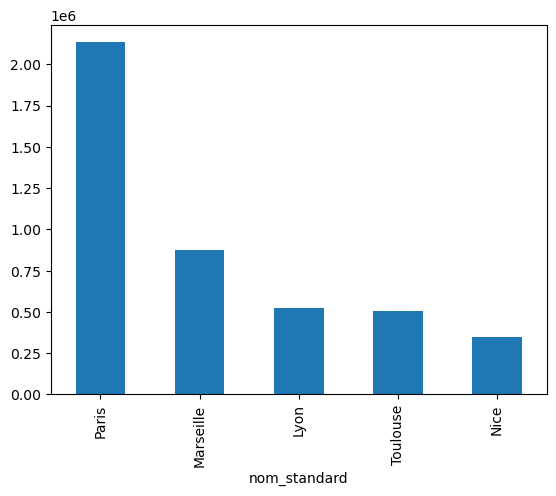

In [106]:
top5.set_index('nom_standard').population.plot(kind='bar') # => matplotlib
# voir gallerie: https://matplotlib.org/stable/gallery/index

In [107]:
stat_funcs = ['min', 'max', 'sum']
stat_by_dep = villes.groupby('dep_code').agg({
    'nom_standard': 'count',
    'population': stat_funcs,
    'superficie_km2': stat_funcs,
})
stat_by_dep

nom_standard population                   superficie_km2          
                count        min      max      sum            min  max  sum
dep_code                                                                   
06                  1     348085   348085   348085             74   74   74
13                  2     147478   873076  1020554            188  241  429
14                  1     108200   108200   108200             26   26   26
21                  1     159346   159346   159346             42   42   42
25                  1     119198   119198   119198             65   65   65
29                  1     139619   139619   139619             49   49   49
30                  1     148104   148104   148104            161  161  161
31                  1     504078   504078   504078            118  118  118
33                  1     261804   261804   261804             50   50   50
34                  1     302454   302454   302454             57   57   57
35                  1     225081   225081   225081             50   50   50
37                  1     137658   137658   137658             33   33   33
38                  1     157477   157477   157477             19   19   19
42                  1     172718   172718   172718             80   80   80
44                  1     323204   323204   323204             66   66   66
45                  1     116617   116617   116617             28   28   28
49                  1     157175   157175   157175             44   44   44
51                  1     179380   179380   179380             47   47   47
54                  1     104260   104260   104260             15   15   15
57                  1     120874   120874   120874             42   42   42
59                  1     236710   236710   236710             35   35   35
63                  1     147327   147327   147327             43   43   43
66                  1     119656   119656   119656             68   68   68
67                  1     291313   291313   291313             78   78   78
68                  1     106341   106341   106341             22   22   22
69                  2     156928   522250   679178             15   48   63
72                  1     145004   145004   145004             53   53   53
74                  1     131715   131715   131715             16   16   16
75                  1    2133111  2133111  2133111            105  105  105
76                  2     114083   166058   280141             21   55   76
80                  1     133625   133625   133625             50   50   50
83                  1     180452   180452   180452             44   44   44
87                  1     129760   129760   129760             80   80   80
92                  1     119808   119808   119808              6    6    6
93                  2     111455   113942   225397              9   12   21
95                  1     107221   107221   107221             17   17   17
974                 2     105240   154765   260005            142  240  382

In [110]:
villes.to_excel('data/villes100k.xlsx', sheet_name='population100k', index=False)

In [113]:
# dependance tierce : openpyxl ou autre
villes2 = pd.read_excel('data/villes100k.xlsx', sheet_name='population100k', dtype=dtypes)
villes2

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
0,Nice,Nice,06,Alpes-Maritimes,06000,348085,74
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
3,Caen,Caen,14,Calvados,14000,108200,26
4,Dijon,Dijon,21,Côte-d'Or,21000,159346,42
5,Besançon,Besançon,25,Doubs,25000,119198,65
6,Brest,Brest,29,Finistère,29200,139619,49
7,Nîmes,Nîmes,30,Gard,30900,148104,161
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
9,Bordeaux,Bordeaux,33,Gironde,33300,261804,50


In [114]:
villes3 = pd.read_json('data/villes100k.json', orient='records')
villes3

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
0,Nice,Nice,6,Alpes-Maritimes,6000,348085,74
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
3,Caen,Caen,14,Calvados,14000,108200,26
4,Dijon,Dijon,21,Côte-d'Or,21000,159346,42
5,Besançon,Besançon,25,Doubs,25000,119198,65
6,Brest,Brest,29,Finistère,29200,139619,49
7,Nîmes,Nîmes,30,Gard,30900,148104,161
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
9,Bordeaux,Bordeaux,33,Gironde,33300,261804,50


In [121]:
villes.to_json('data/villes100k_.json', orient='split', index=False)
villes.to_json('data/villes100k.json', orient='records', index=False, indent=3, force_ascii=False)

In [ ]:
# ami XML: lxml (tiers), etree (stdlib mais moins performant)
villes4 = pd.read_xml('data/villes100k.xml', dtype=dtypes)
villes4

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
0,Nice,Nice,06,Alpes-Maritimes,06000,348085,74
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
3,Caen,Caen,14,Calvados,14000,108200,26
4,Dijon,Dijon,21,Côte-d'Or,21000,159346,42
5,Besançon,Besançon,25,Doubs,25000,119198,65
6,Brest,Brest,29,Finistère,29200,139619,49
7,Nîmes,Nîmes,30,Gard,30900,148104,161
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
9,Bordeaux,Bordeaux,33,Gironde,33300,261804,50


In [128]:
villes.to_xml(
    'data/villes100k_.xml', 
    index=False,
    root_name='Villes',
    row_name='Ville',
    attr_cols=['dep_code', 'code_postal', 'population', 'superficie_km2'],
    elem_cols=['nom_standard', 'nom_sans_pronom']
)

In [125]:
villes.columns

Index(['nom_standard', 'nom_sans_pronom', 'dep_code', 'dep_nom', 'code_postal',
       'population', 'superficie_km2'],
      dtype='str')

### module json
Conversion fichier/str JSON <=> data Python
- lecture : load, loads
- écriture : dump, dumps

In [129]:
with open('data/villes100k.json', encoding='utf-8') as f:
    data = json.load(f)
data

[{'nom_standard': 'Nice',
  'nom_sans_pronom': 'Nice',
  'dep_code': '06',
  'dep_nom': 'Alpes-Maritimes',
  'code_postal': '06000',
  'population': 348085,
  'superficie_km2': 74},
 {'nom_standard': 'Aix-en-Provence',
  'nom_sans_pronom': 'Aix-en-Provence',
  'dep_code': '13',
  'dep_nom': 'Bouches-du-Rhône',
  'code_postal': '13100',
  'population': 147478,
  'superficie_km2': 188},
 {'nom_standard': 'Marseille',
  'nom_sans_pronom': 'Marseille',
  'dep_code': '13',
  'dep_nom': 'Bouches-du-Rhône',
  'code_postal': '13000',
  'population': 873076,
  'superficie_km2': 241},
 {'nom_standard': 'Caen',
  'nom_sans_pronom': 'Caen',
  'dep_code': '14',
  'dep_nom': 'Calvados',
  'code_postal': '14000',
  'population': 108200,
  'superficie_km2': 26},
 {'nom_standard': 'Dijon',
  'nom_sans_pronom': 'Dijon',
  'dep_code': '21',
  'dep_nom': "Côte-d'Or",
  'code_postal': '21000',
  'population': 159346,
  'superficie_km2': 42},
 {'nom_standard': 'Besançon',
  'nom_sans_pronom': 'Besançon',
  

In [130]:
data[0]

{'nom_standard': 'Nice',
 'nom_sans_pronom': 'Nice',
 'dep_code': '06',
 'dep_nom': 'Alpes-Maritimes',
 'code_postal': '06000',
 'population': 348085,
 'superficie_km2': 74}

In [131]:
data[0]['nom_standard']

'Nice'

In [133]:
json.dumps(data[:3])

'[{"nom_standard": "Nice", "nom_sans_pronom": "Nice", "dep_code": "06", "dep_nom": "Alpes-Maritimes", "code_postal": "06000", "population": 348085, "superficie_km2": 74}, {"nom_standard": "Aix-en-Provence", "nom_sans_pronom": "Aix-en-Provence", "dep_code": "13", "dep_nom": "Bouches-du-Rh\\u00f4ne", "code_postal": "13100", "population": 147478, "superficie_km2": 188}, {"nom_standard": "Marseille", "nom_sans_pronom": "Marseille", "dep_code": "13", "dep_nom": "Bouches-du-Rh\\u00f4ne", "code_postal": "13000", "population": 873076, "superficie_km2": 241}]'

### XML
- lib standard Python : xml.etree
- lib tierce : lxml

In [141]:
document = et.parse('data/villes100k_.xml')
document

In [143]:
et.dump(document.getroot())

<Villes>
  <Ville dep_code="06" code_postal="06000" population="348085" superficie_km2="74">
    <nom_standard>Nice</nom_standard>
    <nom_sans_pronom>Nice</nom_sans_pronom>
  </Ville>
  <Ville dep_code="13" code_postal="13100" population="147478" superficie_km2="188">
    <nom_standard>Aix-en-Provence</nom_standard>
    <nom_sans_pronom>Aix-en-Provence</nom_sans_pronom>
  </Ville>
  <Ville dep_code="13" code_postal="13000" population="873076" superficie_km2="241">
    <nom_standard>Marseille</nom_standard>
    <nom_sans_pronom>Marseille</nom_sans_pronom>
  </Ville>
  <Ville dep_code="14" code_postal="14000" population="108200" superficie_km2="26">
    <nom_standard>Caen</nom_standard>
    <nom_sans_pronom>Caen</nom_sans_pronom>
  </Ville>
  <Ville dep_code="21" code_postal="21000" population="159346" superficie_km2="42">
    <nom_standard>Dijon</nom_standard>
    <nom_sans_pronom>Dijon</nom_sans_pronom>
  </Ville>
  <Ville dep_code="25" code_postal="25000" population="119198" superfi

In [146]:
all_population_str = document.xpath('//Ville/@population')
all_population_str

['348085',
 '147478',
 '873076',
 '108200',
 '159346',
 '119198',
 '139619',
 '148104',
 '504078',
 '261804',
 '302454',
 '225081',
 '137658',
 '157477',
 '172718',
 '323204',
 '116617',
 '157175',
 '179380',
 '104260',
 '120874',
 '236710',
 '147327',
 '119656',
 '291313',
 '106341',
 '522250',
 '156928',
 '145004',
 '131715',
 '2133111',
 '166058',
 '114083',
 '133625',
 '180452',
 '129760',
 '119808',
 '111455',
 '113942',
 '107221',
 '154765',
 '105240']

In [153]:
population_13_str = document.xpath("//Ville[@dep_code = '13']/@population")
population_13_str

['147478', '873076']

In [155]:
tab_populations = document.xpath("//Ville/@population")
print(tab_populations)
total = 0
for pop_str in tab_populations:
    pop_int = int(pop_str)
    total += pop_int
print(total)

['348085', '147478', '873076', '108200', '159346', '119198', '139619', '148104', '504078', '261804', '302454', '225081', '137658', '157477', '172718', '323204', '116617', '157175', '179380', '104260', '120874', '236710', '147327', '119656', '291313', '106341', '522250', '156928', '145004', '131715', '2133111', '166058', '114083', '133625', '180452', '129760', '119808', '111455', '113942', '107221', '154765', '105240']
10232650


In [156]:
sum(int(pop_str) for pop_str in document.xpath("//Ville/@population"))

10232650

In [157]:
document.xpath("sum(//Ville/@population)")

10232650.0

In [162]:
# lecture avec validation
xsd = et.XMLSchema(et.parse('data/villes.xsd'))
parser = et.XMLParser(schema=xsd)

document = et.parse('data/villes100k_.xml', parser=parser)
et.dump(document.getroot())

<Villes>
  <Ville dep_code="06" code_postal="06000" population="348085" superficie_km2="74">
    <nom_standard>Nice</nom_standard>
    <nom_sans_pronom>Nice</nom_sans_pronom>
  </Ville>
  <Ville dep_code="13" code_postal="13100" population="147478" superficie_km2="188">
    <nom_standard>Aix-en-Provence</nom_standard>
    <nom_sans_pronom>Aix-en-Provence</nom_sans_pronom>
  </Ville>
  <Ville dep_code="13" code_postal="13000" population="873076" superficie_km2="241">
    <nom_standard>Marseille</nom_standard>
    <nom_sans_pronom>Marseille</nom_sans_pronom>
  </Ville>
  <Ville dep_code="14" code_postal="14000" population="108200" superficie_km2="26">
    <nom_standard>Caen</nom_standard>
    <nom_sans_pronom>Caen</nom_sans_pronom>
  </Ville>
  <Ville dep_code="21" code_postal="21000" population="159346" superficie_km2="42">
    <nom_standard>Dijon</nom_standard>
    <nom_sans_pronom>Dijon</nom_sans_pronom>
  </Ville>
  <Ville dep_code="25" code_postal="25000" population="119198" superfi

In [164]:
# et.parse('data/villes100k.xml', parser=parser)
# XMLSyntaxError: Element 'villes': No matching global declaration available for the validation root.

## Données binaires, Images

In [165]:
with open('data/python-logo.png', mode='rb') as f:
    debut = f.read(1024)
debut

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02D\x00\x00\x00\xa4\x08\x06\x00\x00\x00v;1\xf1\x00\x00\x00\tpHYs\x00\x00\x0b\x13\x00\x00\x0b\x13\x01\x00\x9a\x9c\x18\x00\x00 \x00IDATx\x9c\xed\x9dy\x9c\x1ce\x9d\xff?\xdf\xaa\x9eL\x8e\xc91\xb9\xc8\x1c9\x80If2\xe6 $\x18\x02\x01"+\xcb\x8d\xbb\xca\xa0\x80\xba\xa0\x98\xb0\xa0\xae\xa0\xab.\x1e!\xde\xa2\x0b\xe2\xe2\xc5\x8f\x85\xd5Up\t\xa0\xabBTp3 \x81@\x88\x90\x84\x0c3\x93!\xe4\x98\xcc\x91\xfb>f\xba\x9f\xef\xef\x8f\x99\xee\xae\xae\xae\xe3\xe9\xee\xeak\xe6\xfb~e\xd2=UO=\xcf\xb7jz\xba\xdf\xf3}\x8e"f\x86 \x08\x82 \x08\xc2`\xc6\xc8w\x00\x82 \x08\x82 \x08\xf9F\x84H\x10\x04A\x10\x84A\x8f\x08\x91 \x08\x82 \x08\x83\x1e\x11"A\x10\x04A\x10\x06="D\x82 \x08\x82 \x0czD\x88\x04A\x10\x04A\x18\xf4\x88\x10\t\x82 \x08\x820\xe8\x11!\x12\x04A\x10\x04a\xd0#B$\x08\x82 \x08\xc2\xa0G\x84H\x10\x04A\x10\x84A\x8f\x08\x91 \x08\x82 \x08\x83\x1e\x11"A\x10\x04A\x10\x06="D\x82 \x08\x82 \x0czD\x88\x04A\x10\x04A\x18\xf4\x88\x10\t\x82 \x08\x820\xe8\x11!\x12\x04A\x10\x04a\xd0\x13\x

Size: (580, 164)
Mode: RGBA
Exif: {}


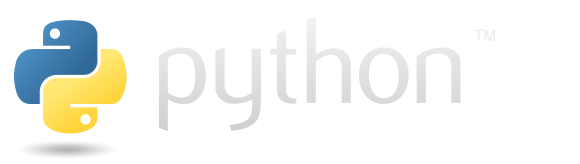

In [ ]:
with Image.open('data/python-logo.png') as im:
    im.load()
    exif = im.getexif()
print("Size:", im.size)
print("Mode:", im.mode)
print("Exif:", exif)
im



## module `re`
Support de Python les expressions régulères (regexp)

In [176]:
pattern = r"(?:[^-]+-[^-]+){2,}"

In [180]:
m = re.search(pattern, "Toulouse")
assert m is None

In [182]:
m = re.search(pattern, "Saint-Etienne")
assert m is None

In [184]:
m = re.search(pattern, "Aix-en-Provence")
assert m is not None
m

<re.Match object; span=(0, 15), match='Aix-en-Provence'>

In [187]:
assert m is not None
print(m.group())
print(m.span())

Aix-en-Provence
(0, 15)


3 fonctions semblables => Match ou None
- `re.match` : correspondance au début du texte
- `re.fullmatch` : texte correspond complètement au pattern
- `re.search` : texte contient le pattern

In [188]:
villes

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
0,Nice,Nice,06,Alpes-Maritimes,06000,348085,74
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
3,Caen,Caen,14,Calvados,14000,108200,26
4,Dijon,Dijon,21,Côte-d'Or,21000,159346,42
5,Besançon,Besançon,25,Doubs,25000,119198,65
6,Brest,Brest,29,Finistère,29200,139619,49
7,Nîmes,Nîmes,30,Gard,30900,148104,161
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
9,Bordeaux,Bordeaux,33,Gironde,33300,261804,50


In [3]:
villes_composees2 = [
    'Saint-Etienne',
    'Clermond-Ferrand',
    'Boulogne-Billancourt',
    'Saint-Denis',
    'Saint-Paul',
    'Toulouse'
]

In [ ]:
pattern = r'([a-z]+)-([a-z]+)' # inclus 2 captures
for ville in villes_composees2:
    m = re.fullmatch(pattern, ville, flags=re.I)
    if m is None:
        print('[SKIP]', ville)
        continue
    print('[MATCH]', ville)
    print('\t- groups:', m.groups())
    mot1, mot2 = m.groups()  # unpack
    print(f"\t- mot #1 = {mot1} ; mot #2 = {mot2}")

[MATCH] Saint-Etienne
	- groups: ('Saint', 'Etienne')
	- mot #1 = Saint ; mot #2 = Etienne
[MATCH] Clermond-Ferrand
	- groups: ('Clermond', 'Ferrand')
	- mot #1 = Clermond ; mot #2 = Ferrand
[MATCH] Boulogne-Billancourt
	- groups: ('Boulogne', 'Billancourt')
	- mot #1 = Boulogne ; mot #2 = Billancourt
[MATCH] Saint-Denis
	- groups: ('Saint', 'Denis')
	- mot #1 = Saint ; mot #2 = Denis
[MATCH] Saint-Paul
	- groups: ('Saint', 'Paul')
	- mot #1 = Saint ; mot #2 = Paul
[SKIP] Toulouse


In [11]:
pattern = r'^[a-z]+-' # inclus 2 captures
for ville in villes_composees2:
    new_ville = re.sub(pattern, '####-', ville, flags=re.I)
    print(new_ville)
    

####-Etienne
####-Ferrand
####-Billancourt
####-Denis
####-Paul
Toulouse


## Scrapping
- requests
- beautiful soup
- scrappy

In [21]:
response = requests.get('https://docs.python.org/3/library/datetime.html')
print(response.status_code)
print(response.headers['content-type'])
page = response.text
print()
print("********** Page lue (extrait) **********")
print(page[:100])

200
text/html

********** Page lue (extrait) **********
<!DOCTYPE html>

<html lang="en" data-content_root="../">
  <head>
    <meta charset="utf-8" />
    


In [23]:
selecteur = "#available-types span.sig-name.descname > span"
soup = BeautifulSoup(page)
elements = soup.select(selecteur)
elements

[<span class="pre">date</span>,
 <span class="pre">time</span>,
 <span class="pre">datetime</span>,
 <span class="pre">timedelta</span>,
 <span class="pre">tzinfo</span>,
 <span class="pre">timezone</span>]

In [24]:
types = [element.text for element in elements]
types

['date', 'time', 'datetime', 'timedelta', 'tzinfo', 'timezone']